In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib import transforms
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import griddata
from scipy.interpolate import interpn
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
from matplotlib.colors import ListedColormap,  LinearSegmentedColormap
cf.go_offline()
%matplotlib inline
import sympy as sp
plt.rcParams["axes.unicode_minus"]=False #negative sign will not be Unicode minus (ie long), but short hyphen

In [2]:
df=pd.read_csv('results.txt',delimiter='\t')

In [3]:
df.head(5)

,time,EP0,EQ,EP*,[PC],[PC+],[Q],[Q-],[PC*],EQh,lambda,Ilamp,Abscoef,k2,Gdiff
0,100000000.0,-0.1,-0.45,-3.00,0.9989,0.0011,0.9989,0.0011,8.997460e-09,-0.275,54392,1,1,100000000.0,16000
1,100000000.0,-0.1,-0.45,-2.95,0.9989,0.0011,0.9989,0.0011,8.997460e-09,-0.275,54392,1,1,100000000.0,16000
2,100000000.0,-0.1,-0.45,-2.90,0.9989,0.0011,0.9989,0.0011,8.997460e-09,-0.275,54392,1,1,100000000.0,16000
3,100000000.0,-0.1,-0.45,-2.85,0.9989,0.0011,0.9989,0.0011,8.997460e-09,-0.275,54392,1,1,100000000.0,16000
4,100000000.0,-0.1,-0.45,-2.80,0.9989,0.0011,0.9989,0.0011,8.997460e-09,-0.275,54392,1,1,100000000.0,16000


<div class="alert alert-block alert-info">
<b> Data cleaning: dropping rows featuring unphysical values; unphysically low concentration values are set to a threshold </b> 
</div>

In [4]:
df.drop(df[(df['[PC]']>1.0) |(df['[PC]']<0.0) |(df['[PC+]']<0.0)|(df['[PC+]']>1.0)
        |(df['[Q]']>1.0) |(df['[Q]']<0.0) |(df['[Q-]']<0.0)|(df['[Q-]']>1.0) 
        |(df['[PC*]']<0.0)|(df['[PC*]']>1.0)].index,inplace=True)
mask = df['[Q-]'] < 5e-13
df.loc[mask, '[Q-]']  = 5e-13
mask = df['[PC+]'] < 5e-13
df.loc[mask, '[PC+]']  = 5e-13

<div class="alert alert-block alert-info">
<b> As we have changed some of the concentrations, the actual quencher redox potentials are recalculated </b> 
</div>

In [5]:
df=df.drop('EQh',axis=1)
df['EQh']=df['EQ']-8.31446*298.15/96485.33212*np.log(df['[Q-]']/df['[Q]'])

<div class="alert alert-block alert-info">
<b> rows still featuring NaN are removed  </b> 
</div>

In [6]:
df[df.isna().any(axis=1)] 
df.dropna(inplace=True)

<div class="alert alert-block alert-info">
<b> Plotting the quencher's actual redox potential as the function of the standard ground state and excited state potential
 of the photocatalysts </b> 
</div>

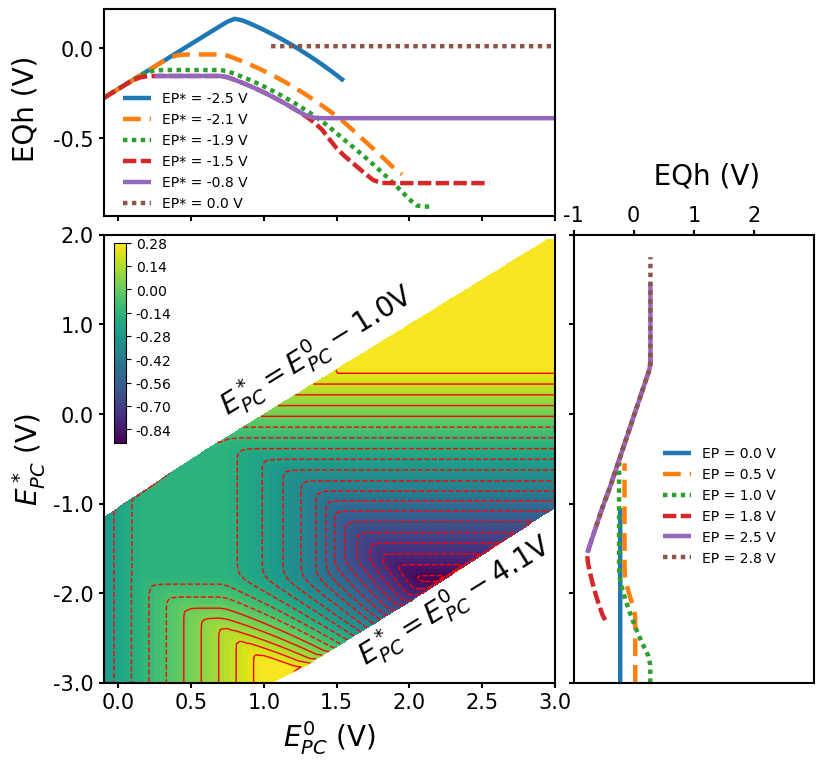

In [7]:
fig = plt.figure(figsize=(10,10))
numcols, numrows = 500,500
xi = np.linspace(df.EP0.min(), df.EP0.max(), numcols)
yi = np.linspace(df['EP*'].min(), df['EP*'].max(), numrows)
xxi, yyi = np.meshgrid(xi, yi)
x, y, z = df.EP0.values, df['EP*'].values, df.EQh.values
m = np.c_[x,y]
zi = griddata(m, z, (xxi, yyi), method='linear') #linear, nearest, cubic
sema = matplotlib.colormaps['viridis'].resampled(256)
newcolors = sema(np.linspace(0, 1, 256))
cmap=ListedColormap(newcolors)

list_EP = [0.0, 0.5, 1.0, 1.8,2.5,2.8]
list_EP_labels = []
for i in range(len(list_EP)):
    list_EP_labels.append("EP = "+ str(list_EP[i])+" V")
list_EPstar = [-2.5, -2.1, -1.9, -1.5, -0.8, 0.0]   #-3 tol +2 ig
list_EPstar_labels = []
for i in range(len(list_EPstar)):
    list_EPstar_labels.append("EP* = "+ str(list_EPstar[i])+" V")
lwi=[3.2 for i in range(10)]
linecol=['#B7E4C7','#95D5B2','#40916C','#40916C','#2D6A4F','#1B4332','#74C69D','#081C15']
linesty=[(0, ()),(0, (4, 2)), (0, (1, 1)),(0, (3, 1)),(0, ()),(0, (1, 1))]#(0, (5, 1))]
linestyle=[] #tuplekent, hogy milyen szinu es milyen vastag a vonal
for i in range(len(list_EP)):
    linestyle.append((linecol[i],lwi[i],linesty[i]))
for i in range(len(list_EPstar)):
    linestyle.append((linecol[i],lwi[i],linesty[i]))
data=[] # for a given EP we look at the EP* - EQh function
for i in range(len(list_EP)):
    df1=df[df['EP0']==list_EP[i]].copy()
    data.append((df1['EP*'],df1['EQh'],list_EP_labels[i],linestyle[i]))
data2=[] # for a given EP* we look at the EP - EQh function
for i in range(len(list_EPstar)):
    df2=df[df['EP*']==list_EPstar[i]].copy()
    data2.append((df2['EP0'],df2['EQh'],list_EPstar_labels[i],linestyle[i]))

ax2=plt.subplot2grid(fig=fig, shape=(48,48),loc=(6,4),rowspan=13, colspan=28)
ax3=plt.subplot2grid(fig=fig, shape=(48,48),loc=(20,33),rowspan=28, colspan=15)
ax4=plt.subplot2grid(fig=fig, shape=(48,48),loc=(20,4),rowspan=28, colspan=28)
    
ax2.set_prop_cycle(color=plt.cm.tab10.colors,lw=lwi)
ax3.set_prop_cycle(color=plt.cm.tab10.colors,lw=lwi)

for d2 in data2: 
    ax2.plot(d2[0], d2[1], label=d2[2],linestyle=d2[3][2])#,c=d2[3][0],lw=d2[3][1])
for d in data: 
    ax3.plot(-d[1], d[0], label=d[2],linestyle=d[3][2])#,c=d[3][0],lw=d[3][1])
ax2.set_xlim(-0.1,3.0)
ax2.set_xticklabels([])
ax2.set_ylabel(" EQh (V)",fontsize=20,labelpad=10)
ax2.legend(frameon=False,loc=(0.03,0.0),fontsize=10)
ax3.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
ax3.xaxis.set_label_position('top')
ax3.set_ylabel("x", rotation=90)
ax3.yaxis.tick_left()
ax3.yaxis.set_label_position("right")
ax3.set_xlabel("   EQh (V)", rotation=0,fontsize=20,labelpad=15)
ax3.invert_xaxis()
ax3.set_xlim(1.0,-3.0)
ax3.set_ylim(-3.0,2.0)
ax3.set(ylabel=None)
ax3.set_xticks([-2, -1, -0.0,1.0])
ax3.set_xticklabels([2,1, 0, -1],rotation=-0.0)
ax3.set_yticklabels([])
ax3.legend(frameon=False,loc=(0.35,0.25),fontsize=10)
ax4.set_xlim(-0.1,3.0)
ax4.set_ylim(-3.0,2.0)
ax4.set_xlabel("$E_{PC}^0$ (V)", rotation=0,fontsize=20)
ax4.set_ylabel("$E_{PC}^*$ (V)", fontsize=20)

surf= ax4.contourf(xxi, yyi, zi, 60, cmap = cmap)
surf2 = ax4.contour(xxi, yyi, zi, 20,linewidths=1.0, colors='r') #this line adds the contourlines to the plot

szel=1.5
labmeret=15
for axis in ['top','bottom','left','right']:
    for axx in [ax2,ax3,ax4]:
        axx.spines[axis].set_linewidth(szel)
        axx.tick_params(width=szel)
        axx.xaxis.set_tick_params(labelsize=labmeret)
        axx.yaxis.set_tick_params(labelsize=labmeret)
ax4.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
x1=ax2.get_position().x0+0.5
y1=ax2.get_position().y0+0.05
cax = fig.add_axes([0.2,0.35,0.012,0.2])
cbar=plt.colorbar(surf,cax=cax)
x1l,x2l=ax4.get_xlim()
y1l,y2l=ax4.get_ylim()
pp=(y2l-y1l)/(x2l-x1l)
x1,x2 = ax4.get_xlim()
y1,y2 = df[df['EP0']==x1]['EP*'].max(), df[df['EP0']==x2]['EP*'].max()
angle=np.rad2deg(np.arctan2((y2-y1),(x2-x1)))
ax4.text(0.5*x1+0.5*x2-0.8, 0.5*y1+0.5*y2-0.4, "$E_{PC}^*= E_{PC}^0 -1.0$V",transform_rotates_text=True,rotation=angle,fontsize=20)
ax4.text(0.5*x1+0.5*x2+0.15, 0.5*y1+0.5*y2-3.2, "$E_{PC}^*= E_{PC}^0 -4.1$V",transform_rotates_text=True,rotation=angle,fontsize=20)
plt.show()